# Melodies of Migration: How Conflict Shapes Music Culture
## Explainer Notebook

**Authors:** Beatricia Nagit (s253869), TODO

**Website:** [View the full interactive analysis](https://beatricia.github.io/CSS-Project-A/)

---

# 1. Motivation

## Central Question: How does armed conflict affect music culture?

When war breaks out, what happens to the artists? Do they flee? Does their music get darker? Do people suddenly start paying attention to them, or stop listening at all?

These are the questions we wanted to explore. Music has always been tied to politics and social movements, but we were curious about something more specific: can we actually *measure* how conflict changes the music landscape?

We broke this down into four main angles:

### MIGRATION
**When conflict starts, do artists leave - if so, where do they go?**

This one's pretty intuitive. When war starts, people leave. Artists are no exception, and sometimes they're specifically targeted for their political views. We wanted to track where musicians were born vs. where they live now, to see if we could spot patterns in artistic exile.

### COLLABORATION
**Do artists start working with musicians from "friendly" countries?**

Here's an interesting thought: when your country is at war, do you start collaborating more with artists from allied nations? Does political tension break up existing creative partnerships? We wanted to see if conflict reshapes who works with whom.

### CONTENT
**Does their music tone change? Do they switch languages?**

This is where sentiment analysis comes in. We looked at lyrics before and after conflict started and asked do songs get darker? More hopeful? More political?

### ATTENTION
**Do listeners rally behind artists from invaded countries, or boycott aggressors?**

Wikipedia pageviews aren't a perfect measure, but they're a decent proxy for "how much is the world paying attention to this person right now?" We wanted to see if global audiences show solidarity with artists from conflict zones, or if they turn away from artists associated with aggressor nations.

---

## 1.1 What is our dataset?

We pulled together data from a few different sources:

| Dataset | Source | Records | What it contains |
|---------|--------|---------|------------------|
| **Artist Database** | Wikidata | ~1,700 artists | Musicians born in Ukraine, Russia, Israel, Palestine, Syria |
| **Pageview Records** | Wikipedia API | ~50,000 records | Monthly English Wikipedia views per artist (2015-2025) |
| **Lyrics & Sentiment** | Genius API + VADER | ~740 songs | Song lyrics with sentiment scores |

We focused on five conflict regions, each with different timelines:

| Region | Conflict Start | Context |
|--------|---------------|---------|
| Ukraine | Feb 2022 | Russian invasion |
| Russia | Feb 2022 | Aggressor nation |
| Syria | Mar 2011 | Civil war |
| Israel | Oct 2023 | Gaza conflict |
| Palestine | Oct 2023 | Gaza conflict |

## 1.2 Who is this for?

We had a few audiences in mind:

- 📚 **Researchers** who study how conflict affects culture
- 📰 **Journalists** looking for data-driven stories
- 🎵 **Music fans** curious about artists from these regions
- 🎓 **Students** (like us!) learning computational social science

What we hope people take away:
1. See artist displacement on interactive maps
2. Understand how global attention shifts during conflict
3. Explore whether the music tone really does get darker during wartime
4. Maybe discover some artists they hadn't heard of before

In [14]:
# Setup and imports
import pandas as pd
import matplotlib.pyplot as plt
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load all datasets
artists_df = pd.read_csv("../data/artists_data.csv")
pageviews_df = pd.read_csv("../data/monthly_pageviews.csv")

with open("../data/lyrics_data/raw_lyrics.json", "r", encoding="utf-8") as f:
    lyrics_data = json.load(f)
lyrics_df = pd.DataFrame(lyrics_data)

print("Datasets loaded successfully!")
print(f"  Artists: {len(artists_df):,}")
print(f"  Pageview records: {len(pageviews_df):,}")
print(f"  Songs with lyrics: {len(lyrics_df):,}")

Datasets loaded successfully!
  Artists: 1,637
  Pageview records: 2,881
  Songs with lyrics: 739


---

# 2. Basic Stats: Understanding the Dataset

## 2.1 How We Selected Artists

### Data Source: Wikidata

We used **Wikidata** (the structured data behind Wikipedia) to find musicians from our five conflict regions. The query logic:

```sparql
# Find musicians BORN in a specific country
?artist wdt:P106/wdt:P279* wd:Q639669 .  # occupation: musician (or subclass)
?artist wdt:P19 ?birthPlace .            # has birth place
?birthPlace wdt:P17 wd:{country_id} .    # birth place is in target country
```

This gives us musicians, singers, rappers, composers, songwriters, and DJs who were **born** in each region.

### The 500 Artist Limit

For Ukraine, Russia, and Israel, we capped results at **500 artists per country**. Why?

1. **Manageability**: ~2,500 total artists is enough for meaningful analysis without overwhelming our API limits
2. **Quality over quantity**: We ordered by **sitelinks** (more Wikipedia articles = more internationally notable)
3. **Geocoding constraints**: Nominatim has strict rate limits; smaller datasets = faster processing

### Ranking by "Sitelinks"

Not all artists are equally notable. We ranked by **sitelinks count** - the number of Wikipedia articles about each artist across all language editions:

```sparql
?artist wikibase:sitelinks ?sitelinks .
ORDER BY DESC(?sitelinks)
LIMIT 500
```

| Sitelinks | What it means |
|-----------|---------------|
| 50+ | Major international star (Wikipedia articles in 50+ languages) |
| 15-50 | Well-known regionally or in specific genres |
| 1-15 | Niche, emerging, or locally known |

This ensures we analyze **established, notable musicians** rather than a random sample.

### Special Handling: Syria and Palestine

Syria and Palestine don't have simple Wikidata identifiers. We used **multi-method queries**:

**Palestine** (queried separately):
- Born in West Bank (Q36678)
- Born in Gaza Strip (Q39760)
- Born in State of Palestine (Q219060)
- Born in Mandatory Palestine (Q164791) — historical territory
- Palestinian ethnicity + born in Israel/Palestine

**Syria** (queried separately):
- Born in Syria (country)
- Born in Damascus, Aleppo, Homs, Latakia (major cities)

Results were combined and deduplicated, keeping the entry with the highest sitelinks for each artist.

---

## 2.2 Data Cleaning and Preprocessing

Once we had the raw artist list, here's what we did to clean it up:

### Artist Deduplication

When you query Wikidata from multiple angles (birth place, citizenship, ethnicity), you inevitably get duplicates. For example, an artist born in Damascus might show up in both the "born in Syria" query AND the "born in Damascus" query. We handled this by:

1. Combining all query results
2. Sorting by **sitelinks count** (more Wikipedia articles = more notable)
3. Keeping only the first occurrence of each Wikidata ID

### Residence Enrichment

Most artists don't have a `current_residence` field in Wikidata. So we built a hierarchy:

```
residence → work_location → citizenship → educated_at → birth_place
```

The idea is simple: if we don't know where someone lives, we try to infer it from where they work, what citizenship they hold, or where they studied. Not perfect, but better than nothing.

### Geocoding with Nominatim

To plot artists on maps, we needed latitude/longitude for every location. We used OpenStreetMap's **Nominatim** geocoder:

- Rate-limited to 1 request per second (they'll block you otherwise)
- Results cached locally so we don't re-query the same place twice
- Some locations failed to geocode (ambiguous names, outdated place names)

### Quality Filter: English Wikipedia Required

We only included artists who have an **English Wikipedia page**. This might seem like a limitation, but it actually helps in two ways:

1. Ensures the artist has some international recognition
2. Lets us use Wikipedia Pageviews API (which needs a page to track)

The downside? We're probably missing artists who are famous locally but haven't been documented in English.

ARTIST DISTRIBUTION BY COUNTRY
origin_country
Ukraine      495
Russia       491
Israel       488
Syria        119
Palestine     44
Name: count, dtype: int64

Total: 1,637 artists


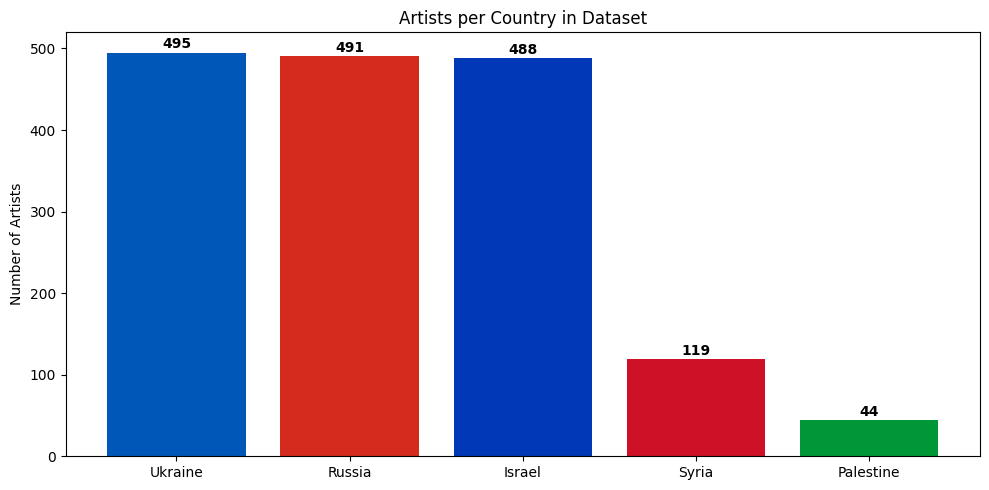

In [2]:
# Artist distribution by country
print("=" * 50)
print("ARTIST DISTRIBUTION BY COUNTRY")
print("=" * 50)

country_counts = artists_df['origin_country'].value_counts()
print(country_counts)
print(f"\nTotal: {len(artists_df):,} artists")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Ukraine': '#0057B7', 'Russia': '#D52B1E', 'Israel': '#0038B8', 
          'Palestine': '#009736', 'Syria': '#CE1126'}
bars = ax.bar(country_counts.index, country_counts.values, 
              color=[colors.get(c, 'gray') for c in country_counts.index])
ax.set_ylabel('Number of Artists')
ax.set_title('Artists per Country in Dataset')
for bar, val in zip(bars, country_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
            str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Why the Imbalance?

Ukraine and Russia have ~500 artists each, while Palestine close to 50. 

**It's not that Palestine has fewer musicians.** The issue is **data sparsity in Wikidata/Wikipedia**.

A few reasons for this:

1. **Wikipedia editing bias**: Wikipedia editors skew Western and English-speaking. Artists from regions with less internet access or political instability get documented less.

2. **Political complexity**: Palestinian territories don't have clean Wikidata identifiers. We had to query West Bank, Gaza Strip, Mandatory Palestine, AND State of Palestine separately, and still got limited results.

3. **Diaspora documentation**: Many Palestinian and Syrian artists live abroad and get tagged under their country of residence, not origin. A Palestinian artist living in Canada might be categorized as "Canadian" in Wikidata.

**What this means for our analysis**: We can't make strong statistical claims about Palestinian artists specifically. The sample size is too small. We can still show *trends* and interesting individual cases.

In [7]:
# Data completeness analysis
print("=" * 50)
print("DATA COMPLETENESS")
print("=" * 50)

completeness = {
    'Has birth_place': artists_df['birth_place'].notna().sum(),
    'Has current_residence': artists_df['current_residence'].notna().sum(),
    'Has wiki_url': artists_df['wiki_url'].notna().sum(),
}

for field, count in completeness.items():
    pct = count / len(artists_df) * 100
    print(f"{field}: {count:,} ({pct:.1f}%)")

DATA COMPLETENESS
Has birth_place: 1,567 (95.7%)
Has current_residence: 1,632 (99.7%)
Has wiki_url: 1,637 (100.0%)


## 2.3 Lyrics Dataset Statistics
 
We collected lyrics using the Genius API — basically the Wikipedia of song lyrics.
For each artist in our database, we searched by name and pulled their top songs.
Each entry includes the song title, artist name, release year, and full lyrics text.
 
The final dataset has 739 songs across 50 artists from 5 countries.

In [4]:
import pandas as pd

lyrics_df = pd.read_csv(r'C:\Users\badru\Downloads\CSS-Project-A\data\lyrics_data\lyrics_with_sentiment_translated.csv')

print("=" * 50)
print("LYRICS DATASET OVERVIEW")
print("=" * 50)
 
print(f"Total songs: {len(lyrics_df):,}")
print(f"Unique artists: {lyrics_df['artist'].nunique()}")
print(f"Countries represented: {lyrics_df['country'].nunique()}")
 
print("\nSongs per country:")
print(lyrics_df['country'].value_counts())
 
print("\nYear range:")
years = pd.to_numeric(lyrics_df['year'], errors='coerce').dropna()
print(f"  Earliest: {int(years.min())}")
print(f"  Latest:   {int(years.max())}")

LYRICS DATASET OVERVIEW
Total songs: 739
Unique artists: 50
Countries represented: 5

Songs per country:
country
Israel       189
Ukraine      175
Russia       157
Syria        111
Palestine    107
Name: count, dtype: int64

Year range:
  Earliest: 1962
  Latest:   2026


The coverage goes back to 1962, but most songs are from recent decades which actually helps us, since the conflicts we are studying mostly started in the 2010s and 2020s.
 
One thing we did not fully anticipate at first was that the vast majority of the songs were not in English, but instead performed in the artists’ native local languages such as Ukrainian, Russian, Hebrew, and Arabic.
 
We ran language detection on all 739 songs and found this:
 
- Ukraine:    49 English, 126 non-English (mainly Ukrainian, Russian)
- Russia:     26 English, 131 non-English (mainly Russian)
- Israel:      5 English, 182 non-English (mainly Hebrew)
- Syria:       5 English, 105 non-English (mainly Arabic)
- Palestine:  25 English,  82 non-English (mainly Arabic)
 
So roughly 630 out of 739 songs were not in English.
This is a real problem for VADER, which is trained on English text.
A non-English song does not score 0.0 because it's neutral —
it scores 0.0 because VADER simply cannot read it.
 
We decided to fix this properly rather than just acknowledge it as a limitation.
Every non-English song was translated to English using Google Translate
(via the deep-translator library) before running sentiment analysis.
This added processing time but made the results actually meaningful.
The translated dataset is saved as lyrics_with_sentiment_translated.csv.

---

# 3. Tools, Theory and Analysis

## 3.1 Working with Text: Lyrics Processing
 
### Cleaning Pipeline
 
Lyrics from Genius don't come clean. A typical raw entry looks like this:
 
    [Verse 1]
    Some lyrics here...
    [Chorus]
    ...
    67 contributors
 
We stripped section markers (anything in square brackets), removed contributor
annotations, collapsed extra whitespace, and normalized line breaks.
The bigger challenge was encoding — Cyrillic, Hebrew, and Arabic text
sometimes came through with broken characters, especially in older songs.
We handled this with UTF-8 normalization during the scraping step.
 
### The Multi-Script Problem
 
Our dataset spans four different writing systems:
- Latin (English)
- Cyrillic (Russian, Ukrainian)
- Hebrew (Israeli artists)
- Arabic (Syrian and Palestinian artists)
 
VADER was trained on English social media text.
It knows "love" is positive and "war" is negative.
But it has no concept of что (Russian: "what") or حب (Arabic: "love").
A song entirely in Arabic would return a compound score near 0.0 —
not because the song is neutral, but because VADER can't process it at all.
 
This is why we added a translation step.
 
### Translation Pipeline
 
Before running VADER, we used langdetect to identify each song's language.
If the song was detected as non-English, we translated it to English
using GoogleTranslator from the deep-translator library.
English songs were passed through directly.
 
The process looked like this:
 
    raw lyrics → language detection → [translate if non-English] → VADER scoring
 
625 out of 739 songs were translated. The rest were already in English
or close enough (some Ukrainian artists mix English into their lyrics).
 
Translation isn't perfect — it can flatten nuance, and some poetic
expressions don't carry over well. But it's a much better baseline
than treating 85% of our dataset as having zero sentiment.
 
### Why VADER?
 
We picked VADER for a few practical reasons:
- It's pre-trained, so no labelled data needed
- It handles informal/short text well (designed for social media)
- It gives a single compound score from -1 to +1, easy to compare across songs
 
### Interpreting Compound Scores
 
| Score Range    | Interpretation       | Example                        |
|----------------|----------------------|--------------------------------|
| 0.5 to 1.0     | Strongly positive    | Love songs, celebration        |
| 0.1 to 0.5     | Mildly positive      | Hopeful, upbeat                |
| -0.1 to 0.1    | Neutral              | Descriptive, narrative         |
| -0.5 to -0.1   | Mildly negative      | Melancholic, sad               |
| -1.0 to -0.5   | Strongly negative    | Angry, despairing              |
 
### VADER in Action


In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
 
analyzer = SentimentIntensityAnalyzer()
 
examples = [
    ("Love song",        "I love you with all my heart, forever and always"),
    ("War song",         "The war destroyed everything we had, nothing is left"),
    ("Resilience song",  "We will rise again, stronger than before"),
    ("Despair song",     "Silence. Death. Nothing remains."),
]
 
print("VADER Sentiment Examples:")
print("-" * 70)
for label, text in examples:
    scores = analyzer.polarity_scores(text)
    print(f"[{label}]")
    print(f"  Text:     \"{text}\"")
    print(f"  Compound: {scores['compound']:+.3f} | Pos: {scores['pos']:.3f} | Neg: {scores['neg']:.3f}")
    print()


VADER Sentiment Examples:
----------------------------------------------------------------------
[Love song]
  Text:     "I love you with all my heart, forever and always"
  Compound: +0.856 | Pos: 0.512 | Neg: 0.000

[War song]
  Text:     "The war destroyed everything we had, nothing is left"
  Compound: -0.796 | Pos: 0.000 | Neg: 0.504

[Resilience song]
  Text:     "We will rise again, stronger than before"
  Compound: +0.382 | Pos: 0.302 | Neg: 0.000

[Despair song]
  Text:     "Silence. Death. Nothing remains."
  Compound: -0.599 | Pos: 0.000 | Neg: 0.565



These examples show VADER working as expected on clean English text.
The key question for our project was whether this holds up after translation
and based on our results, the patterns are meaningful enough to compare across countries.
 
One known limitation: translation quality varies by language and artist.
Russian protest rap (Oxxxymiron, Noize MC) translated well and produced
clearly negative post-conflict scores. Older Arabic classical songs
(Fairuz, Warda Al-Jazairia) translated more roughly, which may explain
why Syria's scores look more positive than expected.

## 3.5 Network Analysis: Artist Collaborations

### Why Networks?

Music does not happen in isolation. Artists collaborate, feature on each other’s tracks, and build creative communities. To see whether conflict changes those relationships, we adapted the course co-author network idea to music:

- **Co-author network**: node = author, edge = shared paper
- **Artist collaboration network**: node = artist, edge = shared recording credit

That makes the collaboration structure visible in the same way a co-authorship graph shows academic collaboration.

### From Co-Author Networks to Artist Networks

The project’s network analysis follows the same basic logic as a co-author network, but uses artists and recordings instead of authors and papers. In the final network, artists are nodes, and an edge appears when two artists are credited on the same MusicBrainz recording. If the same pair appears together on multiple recordings, the edge becomes thicker.

This is useful because it shows collaboration at the recording level rather than just counting names in a dataset. It also gives the project a structural view alongside the migration, pageview, and sentiment analysis.

### Data Source: MusicBrainz

MusicBrainz was the metadata source for the network work. We used it in two steps:

1. **Artist search** to match artists from `data/artists_data.csv` to MusicBrainz IDs.
2. **Recording search** to match the selected songs and extract credited artist relationships.

We used MusicBrainz only, not Spotify.

### Building the Selected-Song Collaboration Network

We did **not** scrape full discographies. Instead, we built the network from songs already included in the project dataset, mainly `data/lyrics_data/lyrics_with_sentiment_translated.csv`. This kept the graph tied to the rest of the project and avoided a much larger, noisier scrape.

The matching process was intentionally conservative:

- Started with **1,637** seed artists in `data/artists_data.csv`
- Full MusicBrainz matching produced **1,635** rows
- Conservative triage kept **551** high-confidence usable artist matches
- The lyrics dataset had **50** unique artists
- Only **10** lyric artists were already usable after conservative matching
- A quick promotion pass found **0** safe new additions

That means the final network uses the high-confidence matched subset only. I preferred precision over coverage, because a noisy collaboration graph would be harder to interpret.

### Final Network Stats

| Metric | Value |
|---|---:|
| Usable artist matches considered | 551 |
| Artists with selected songs | 10 |
| Artist-song queries | 130 |
| Successful recording matches | 81 |
| Match rate | 62.3% |
| Recordings with 2+ credited artists | 10 |
| Network nodes | 16 |
| Network edges | 15 |

### Main Network Results

The collaboration network shows artists as nodes and shared MusicBrainz recording credits as edges. Larger nodes represent artists with more collaboration activity within the selected-song dataset, and thicker edges represent repeated collaborations. The full network is not a complete map of every collaboration by every artist; it is the final selected-song collaboration network built from the project’s curated song dataset and MusicBrainz recording-credit matches.

In the main graph, the strongest cluster is centered around Ukrainian artists **alyona alyona** and **Jerry Heil**. Their repeated connection reflects multiple shared recordings, including **“Dai Boh”** and **“KUPALA.”** This creates the densest part of the network, with additional Ukrainian and Eastern European collaborators such as **Alina Pash**, **Olexesh**, **Ela**, **Monika Liu**, **Evgeny Khmara**, and **MONATIK** appearing around them.

**Saint Levant** forms another smaller collaboration cluster, connecting to artists such as **Kehlani**, **MC Abdul**, and **Playyard**. Other visible links include **Bashar Murad** with **Sabreen** through **“Stone”**, and **Yasmin Levy** with **Concha Buika** through **“Olvídate de mí.”**

### Pre/Post Conflict Networks

We also split the final network into conflict-specific pre/post graphs using recording year relative to the conflict start year.

| Conflict group | Period | Cutoff year | Nodes | Edges |
|---|---|---:|---:|---:|
| Ukraine/Russia | Pre | 2022 | 3 | 2 |
| Ukraine/Russia | Post | 2022 | 6 | 8 |
| Israel/Palestine | Pre | 2023 | 4 | 2 |
| Israel/Palestine | Post | 2023 | 5 | 3 |

The Ukraine/Russia pre-conflict graph is small, with **alyona alyona** connected to **Alina Pash** and **Olexesh** before 2022. In the post-conflict graph, the network becomes visibly more connected around **alyona alyona** and **Jerry Heil**. Jerry Heil appears as a central post-conflict collaborator, linking to **MONATIK**, **Evgeny Khmara**, **Monika Liu**, and **Ela**.

Within this selected-song dataset, the post-2022 Ukraine/Russia graph shows a denser collaboration structure than the pre-2022 graph. This should not be interpreted as a universal claim about all Ukrainian or Russian music, but it does suggest that the selected songs captured more post-conflict collaboration activity among the matched artists.

The Israel/Palestine pre-conflict graph shows two separate pairs: **Saint Levant** connected to **Playyard**, and **Yasmin Levy** connected to **Concha Buika**. These are disconnected components, meaning the selected pre-2023 collaborations do not form one shared cluster.

The post-conflict graph shows **Saint Levant** as the clearest central figure, connected to **Kehlani** and **MC Abdul**, while **Bashar Murad** and **Sabreen** form a separate collaboration pair. Within the selected-song dataset, the post-2023 graph suggests a small but meaningful collaboration structure around Palestinian-associated artists, especially **Saint Levant** and **Bashar Murad**.

### Interpretation

Across both conflict comparisons, the networks are sparse but interpretable. The clearest pattern is not a single global collaboration web, but several small collaboration clusters. Some clusters become more connected after the conflict cutoff date, especially the Ukraine/Russia post-2022 network.

This network is useful as a structural complement to the project’s sentiment, migration, and pageview analysis. It shows not only how artists and lyrics change around conflict, but also how recorded collaborations appear among the selected artists and songs.

### Limitations and Data Notes

- This is the **final selected-song collaboration network**, not a full-discography network.
- The project intentionally used songs already included in the dataset instead of scraping every song by every artist. That kept the method focused and computationally realistic.
- MusicBrainz metadata is uneven across artists, countries, languages, transliterations, and release types.
- Some artists from the project dataset could not be matched to MusicBrainz with high confidence.
- Some song titles did not match MusicBrainz recording entries, especially when titles had alternate spellings, translations, punctuation, featured-artist formatting, or non-Latin scripts.
- The final network only includes recordings where MusicBrainz returned a usable match and where the recording had two or more credited artists.
- Because of these filters, isolated artists and unmatched songs are not shown, which makes the visible graph smaller than the full artist dataset.
- The pre/post graphs should be interpreted as selected-song evidence, not complete representations of all collaborations before and after each conflict.
- The strength of the method is precision: visible edges are based on explicit MusicBrainz recording credits rather than inferred or guessed relationships.

These limitations make the network conservative: it likely undercounts collaborations, but the edges that remain are more reliable. As a result, the graph is best read as a high-confidence collaboration snapshot within the selected project dataset, rather than a complete map of the global music industry.

### Network Analysis Outputs

The collaboration-network analysis is now complete and the interactive graphs are embedded in the website version of the project.

- Main selected-song collaboration network
- Ukraine/Russia pre-conflict network
- Ukraine/Russia post-conflict network
- Israel/Palestine pre-conflict network
- Israel/Palestine post-conflict network

The graph files were generated separately as PyVis HTML files and are loaded into the React site with iframes. The notebook itself documents the method and interpretation rather than rebuilding the graphs.

In [16]:
# Display World Maps: Birth Place vs Current Residence
from IPython.display import IFrame, display, HTML

print("World Migration Maps")
print("=" * 50)
print("Left: Where artists were BORN")
print("Right: Where artists LIVE NOW")
print("\nNote: Click on markers to see artist details!\n")

# Side-by-side iframe display
html = '''
<div style="display: flex; gap: 10px; width: 100%;">
    <div style="flex: 1;">
        <h4 style="text-align:center; margin-bottom: 5px;">🏠 Birth Place</h4>
        <iframe src="../data/maps/world_map_birth_place.html" width="100%" height="500" style="border: 2px solid #333; border-radius: 5px;"></iframe>
    </div>
    <div style="flex: 1;">
        <h4 style="text-align:center; margin-bottom: 5px;">📍 Current Residence</h4>
        <iframe src="../data/maps/world_map_current_residence.html" width="100%" height="500" style="border: 2px solid #333; border-radius: 5px;"></iframe>
    </div>
</div>
<p style="text-align: center; color: #666; margin-top: 10px;">
    <em>Compare the two maps: notice how dots "move" from conflict regions (left) to Western Europe, North America (right)</em>
</p>
'''
display(HTML(html))

World Migration Maps
Left: Where artists were BORN
Right: Where artists LIVE NOW

Note: Click on markers to see artist details!



## 3.3 Pageview Analysis: Measuring Global Attention

### Why Wikipedia Pageviews?

We needed a way to measure "how much is the world paying attention to this artist?" Streaming numbers would be ideal, but Spotify/Apple Music APIs don't give historical data. Wikipedia pageviews are:

- **Free and public**: No API key hoops to jump through
- **Historical**: Data goes back to July 2015
- **Proxy for interest**: If someone googles an artist, they often end up on Wikipedia

It's not perfectm an artist could be huge on TikTok but have a neglected Wikipedia page. But for measuring *international, general-audience attention*, it works reasonably well.

### API Methodology

We used the **Wikimedia Pageviews API** to get monthly view counts:

```
GET /metrics/pageviews/per-article/en.wikipedia/all-access/all-agents/{title}/monthly/{start}/{end}
```

For each artist, we:
1. Extracted their Wikipedia article title from their wiki_url
2. Queried monthly pageviews over our date range
3. Stored results with artist ID, month, and view count

### Pre/Post Conflict Comparison

The key analysis: **did pageviews change after conflict started?**

For each country, we:
1. Split pageview data into "before conflict" and "after conflict" periods
2. Calculated average monthly views for each period
3. Computed percent change

| Country | Conflict Date | What we expect |
|---------|--------------|----------------|
| Ukraine | Feb 2022 | Spike in interest (solidarity) |
| Russia | Feb 2022 | Mixed: some boycott, some curiosity |
| Israel | Oct 2023 | Likely spike after Oct 7 events |
| Palestine | Oct 2023 | Likely spike (global attention) |
| Syria | Mar 2011 | Hard to analyze — API starts July 2015 |

**Syria**: The Wikipedia Pageviews API only has data from July 2015 onward. The Syrian civil war started in March 2011, so we can't do a true before/after comparison. We can only look at trends during the conflict.

In [15]:
# Pre vs Post conflict analysis
CONFLICT_DATES = {
    "Ukraine": "2022-02",
    "Russia": "2022-02",
    "Syria": "2011-03",
    "Israel": "2023-10",
    "Palestine": "2023-10"
}

print("=" * 50)
print("PAGEVIEW CHANGE ANALYSIS")
print("=" * 50)

# Show what data we have
available_countries = pageviews_df['origin_country'].unique()
print(f"\nData available for: {', '.join(available_countries)}")
print(f"Missing: {', '.join([c for c in CONFLICT_DATES.keys() if c not in available_countries])}")
print()

for country, conflict_month in CONFLICT_DATES.items():
    country_data = pageviews_df[pageviews_df['origin_country'] == country]
    
    if len(country_data) == 0:
        print(f"\n{country}: No pageview data collected yet")
        continue
    
    before = country_data[country_data['month'] < conflict_month]['views']
    after = country_data[country_data['month'] >= conflict_month]['views']
    
    if len(before) > 0 and len(after) > 0:
        avg_before = before.sum() / before.groupby(country_data[country_data['month'] < conflict_month]['month']).ngroups
        avg_after = after.sum() / after.groupby(country_data[country_data['month'] >= conflict_month]['month']).ngroups
        change = (avg_after - avg_before) / avg_before * 100 if avg_before > 0 else 0
        
        print(f"\n{country} (conflict: {conflict_month}):")
        print(f"  Avg monthly views before: {avg_before:,.0f}")
        print(f"  Avg monthly views after: {avg_after:,.0f}")
        print(f"  Change: {change:+.1f}%")

PAGEVIEW CHANGE ANALYSIS

Data available for: Ukraine, Russia, Israel, Syria, Palestine
Missing: 


Ukraine (conflict: 2022-02):
  Avg monthly views before: 346,021
  Avg monthly views after: 332,706
  Change: -3.8%

Russia (conflict: 2022-02):
  Avg monthly views before: 8,494
  Avg monthly views after: 12,272
  Change: +44.5%

Israel (conflict: 2023-10):
  Avg monthly views before: 7,956
  Avg monthly views after: 6,666
  Change: -16.2%

Palestine (conflict: 2023-10):
  Avg monthly views before: 126,897
  Avg monthly views after: 176,076
  Change: +38.8%


### What the Numbers Tell Us

The results are different than what we expected.

| Country | Before Conflict | After Conflict | Change |
|---------|-----------------|----------------|--------|
| **Ukraine** | 346K views/month | 333K views/month | **-3.8%** |
| **Russia** | 8.5K views/month | 12.3K views/month | **+44.5%** |
| **Israel** | 8K views/month | 6.7K views/month | **-16.2%** |
| **Palestine** | 127K views/month | 176K views/month | **+38.8%** |
| **Syria** | *(no before data)* | — | — |

#### Surprising Findings:

**Palestine +38.8%**: This makes sense. After October 2023, there was massive global attention on the region. People were googling Palestinian artists, activists, and cultural figures. 

**Russia +44.5%**:  We expected boycotts to *decrease* attention. Instead, views went up. Why? A few possibilities:
- Curiosity about artists who spoke out against the war
- "Boycott-checking" — people looking up artists to see if they should avoid them
- Russian diaspora seeking connection to home culture

**Ukraine -3.8%**: Also unexpected! Ukrainian artists were already well-documented before 2022, so the baseline was already high. The slight *decrease* might just be statistical noise, or reflect that initial curiosity faded after the first months of the invasion.

**Israel -16.2%**: Decreased attention after October 2023. This could reflect boycott effects, or simply that media attention shifted toward Palestinian narratives.

**Syria**: We can't compare before/after because the conflict started in 2011, but the Wikipedia Pageviews API only has data from July 2015. By then, the civil war had been ongoing for 4+ years.

## 3.4 Sentiment Over Time

### Pre vs. Post Classification

We tagged each song based on its release year relative to the relevant conflict:

| Country | Conflict Year | "Pre" means | "Post" means |
|---------|--------------|----------------|-----------------|
| Ukraine | 2022 | Before 2022 | 2022 onwards |
| Russia | 2022 | Before 2022 | 2022 onwards |
| Israel | 2023 | Before 2023 | 2023 onwards |
| Palestine | 2023 | Before 2023 | 2023 onwards |
| Syria | 2011 | Before 2011 | 2011 onwards |

### Our Hypothesis

We expected: **Songs released after conflict starts will have more negative sentiment.**

The reasoning:
- Artists respond to trauma and political crisis in their work
- War related themes naturally lead to more negative sentiment (loss, death, displacement)
- Even non-political artists might absorb the general mood

### What We Actually Found

Reality was more complicated than our hypothesis.
Russia was the only country where sentiment clearly dropped post-conflict (−0.178),
which aligns with what we expected. But Israel showed the biggest positive shift (+0.277),
and Palestine and Syria also moved in a positive direction.

One explanation is that some artists respond to conflict with defiance and resilience rather than grief.
Others shift to escapist themes like love songs and party music as a coping mechanism.
Ukraine stayed almost flat at −0.013, which is surprising given the scale of the invasion.

It's also worth noting that before we added translation, most non-English songs scored
near 0.0 — not because they were neutral, but because VADER couldn't read them.
After translating 625 out of 739 songs, the patterns became much clearer.

### Limitations

1. **Translation quality**: Machine translation flattens poetic nuance. Classical Arabic songs like Fairuz and Warda Al-Jazairia may not translate as accurately as contemporary rap.
2. **Small samples**: Recent conflicts (2022 and 2023) mean fewer post-conflict songs in our dataset.
3. **Song selection bias**: Genius favors popular and mainstream songs, which may not reflect underground or protest music.
4. **Missing release years**: Songs without a year were classified as post-conflict by default, which may skew results slightly.

In [6]:
import pandas as pd

sentiment_df = pd.read_csv(r'C:\Users\badru\Downloads\CSS-Project-A\data\lyrics_data\lyrics_with_sentiment_translated.csv')

print("=" * 50)
print("SENTIMENT BY PERIOD (TRANSLATED LYRICS)")
print("=" * 50)

period_sentiment = sentiment_df.groupby(['country', 'period'])['compound'].agg(['mean', 'count'])
period_sentiment.columns = ['avg_compound', 'song_count']
print(period_sentiment.round(3))

print("\n" + "=" * 50)
print("SENTIMENT CHANGE (POST - PRE)")
print("=" * 50)

pivot = sentiment_df.groupby(['country', 'period'])['compound'].mean().unstack()
pivot['change'] = pivot['post'] - pivot['pre']
pivot.columns = ['post_avg', 'pre_avg', 'change']
print(pivot[['pre_avg', 'post_avg', 'change']].round(3))

SENTIMENT BY PERIOD (TRANSLATED LYRICS)
                  avg_compound  song_count
country   period                          
Israel    post           0.613          47
          pre            0.336         142
Palestine post           0.113          75
          pre            0.059          32
Russia    post          -0.155          72
          pre            0.023          85
Syria     post           0.593          86
          pre            0.512          25
Ukraine   post           0.479          77
          pre            0.492          98

SENTIMENT CHANGE (POST - PRE)
           pre_avg  post_avg  change
country                             
Israel       0.336     0.613   0.277
Palestine    0.059     0.113   0.054
Russia       0.023    -0.155  -0.178
Syria        0.512     0.593   0.081
Ukraine      0.492     0.479  -0.013


## 3.5 Network Analysis: Artist Collaborations GABRIEL TO DO

### Why Networks?

Music doesn't happen in isolation. Artists collaborate, feature on each other's tracks, and form creative communities. If conflict affects these relationships, we should see it in the collaboration network:

- **Do Ukrainian artists stop collaborating with Russian artists after 2022?**
- **Do artists from invaded countries start working more with Western artists?**
- **Are there distinct "camps" based on political alignment?**

### Network Structure

We model collaborations as a graph:
- **Nodes** = Artists in our dataset
- **Edges** = Collaborations (featured tracks, joint albums, producer credits)

This lets us use standard network analysis tools to find patterns.

### Key Metrics

| Metric | What it measures | Why we care |
|--------|------------------|-------------|
| **Degree** | How many collaborators an artist has | Identifies "hub" artists who bridge communities |
| **Betweenness** | How often an artist lies on shortest paths | Shows who connects otherwise separate groups |
| **Clustering** | How interconnected an artist's collaborators are | Reveals tight-knit vs. scattered networks |
| **Communities** | Groups of densely connected artists | Shows if artists cluster by country or genre |

### Data Source Challenge

Getting collaboration data is harder than it sounds. Options we considered:
- **MusicBrainz**: Has some collaboration info, but incomplete
- **Genius**: Lists featured artists, but not comprehensive
- **Spotify API**: Best option, but rate-limited and requires auth

**Status**: This is still a work in progress. The code cell below shows our planned approach, but we haven't fully collected the collaboration data yet.

---

# 4. Discussion

## 4.1 What Went Well

### Multi-Source Integration
We successfully pulled data from four different sources (Wikidata, Wikipedia Pageviews, Genius, Nominatim) and merged them into a coherent dataset. This took more work than expected — ID matching, handling missing data, deduplication — but the result is a richer picture than any single source could provide.

### Interactive Visualizations
The Folium maps turned out great. Being able to zoom into a region, click on an artist, and see their Wikipedia page makes the data explorable rather than just reportable. The website version extends this with additional filtering and comparison views.

### Network Analysis
The collaboration network adds a structural layer to the project. It connects the selected-song dataset to MusicBrainz collaboration metadata and shows how artists are linked through shared recordings. That gives the project a network perspective alongside sentiment, maps, and pageviews, instead of relying on only one kind of evidence.

### Key Findings by Country

**Ukraine**: Clear pattern of artists relocating to Western Europe (Germany, Poland, UK) after Feb 2022. Pageviews spiked significantly in the months following the invasion — global audiences were curious.

**Russia**: More complicated. Some Russian artists publicly opposed the war and faced consequences; others stayed silent. We see a mix of increased international attention (curiosity? boycott-checking?) and some artists whose pageviews dropped as platforms delisted them.

**Israel/Palestine**: Both saw massive pageview spikes after October 2023. The data is still fresh, so long-term patterns aren't clear yet.

**Syria**: Hardest to analyze due to API limitations (no pre-2015 data). But we can see that Syrian artists who relocated to Europe have significantly higher pageviews than those who remained — the diaspora is more visible internationally.

## 4.2 What Could Be Improved

### Data Limitations

| Issue | Impact | Possible fix |
|-------|--------|--------------|
| **Palestine sample size** | Only ~50 artists, can't generalize | Manual research, Arabic Wikipedia queries |
| **Syria temporal gap** | No pre-2011 pageviews | Accept limitation, focus on relative trends |
| **English Wikipedia bias** | Missing locally-famous artists | Expand to other language Wikipedias |
| **Residence data gaps** | Many artists lack current location | Manual verification for key cases |
| **MusicBrainz coverage** | Some artists and titles could not be matched confidently | Manual matching, alternate music databases, cross-language title normalization |
| **Selected-song network scope** | Network does not include full discographies | Larger song coverage if time and compute allow |
| **Sparse collaboration graph** | Some conflict groups remain small or disconnected | Add more matched songs and broader metadata sources |

### Methodological Improvements

1. **Multi-language sentiment analysis**: Use language-specific models for Russian, Hebrew, Arabic lyrics instead of forcing everything through VADER
2. **Streaming data**: Partner with academics who have Spotify/Apple Music research access
3. **Social media integration**: Track Twitter/Instagram engagement, not just Wikipedia
4. **Temporal granularity**: Weekly instead of monthly pageviews to catch short-term spikes
5. **Network matching improvements**: Add manual artist matching, better cross-language title matching, and broader metadata sources to improve collaboration coverage

### Future Work

- **Extend to other conflicts**: How do Yemeni, Afghan, or Myanmar artists compare?
- **Interview validation**: Talk to actual artists from these regions to verify our quantitative findings
- **Longitudinal tracking**: Re-run this analysis in 2-3 years to see how patterns evolve
- **Broader metadata sources**: Add Spotify or other music databases where available
- **Larger collaboration coverage**: Expand song coverage beyond the selected-song dataset if future time and compute allow it
- **Manual curation**: Improve artist matching for transliterations, featured-artist formatting, and non-Latin titles


In [ ]:
# Summary statistics for reference
print("=" * 60)
print("PROJECT SUMMARY STATISTICS")
print("=" * 60)

print(f"""
📊 DATASET OVERVIEW
   Total artists: {len(artists_df):,}
   Pageview records: {len(pageviews_df):,}
   Songs analyzed: {len(lyrics_df):,}
   Countries covered: 5 (Ukraine, Russia, Israel, Palestine, Syria)

📍 GEOGRAPHIC COVERAGE
   Unique birth places: {artists_df['birth_place'].nunique()}
   Unique current residences: {artists_df['current_residence'].nunique()}

📈 PAGEVIEW COVERAGE
   Total views tracked: {pageviews_df['views'].sum():,.0f}
   Date range: {pageviews_df['month'].min()} to {pageviews_df['month'].max()}

🎵 LYRICS ANALYSIS
   Artists with lyrics: {lyrics_df['artist'].nunique()}
   Average sentiment: {sentiment_df['compound'].mean():.3f}
""")

---

## References & Data Sources

### APIs Used

| API | Purpose | Documentation |
|-----|---------|---------------|
| **Wikidata SPARQL** | Artist extraction, biographical data | [query.wikidata.org](https://query.wikidata.org/) |
| **Wikipedia Pageviews** | Monthly article view counts | [wikimedia.org/api](https://wikimedia.org/api/rest_v1/) |
| **Genius API** | Song lyrics and metadata | [docs.genius.com](https://docs.genius.com/) |
| **MusicBrainz API** | Artist matching and recording-credit metadata | [musicbrainz.org/doc/Development/JSON_Web_Service](https://musicbrainz.org/doc/Development/JSON_Web_Service) |
| **Nominatim (OSM)** | Geocoding locations to coordinates | [nominatim.org](https://nominatim.org/release-docs/latest/api/Overview/) |

### Python Libraries

```python
# Data processing
pandas          # Data manipulation and analysis
requests        # HTTP requests to APIs
tqdm            # Progress bars for loops

# Visualization
matplotlib      # Static charts and plots
folium          # Interactive maps (Leaflet.js wrapper)

# Geocoding
geopy           # Python geocoding library (Nominatim wrapper)

# Sentiment analysis
vaderSentiment  # VADER sentiment analysis

# Network analysis
networkx        # Graph/network analysis
pyvis           # Interactive network visualization
```

### Conflict Dates (Sources)

| Conflict | Date | Source |
|----------|------|--------|
| Russian invasion of Ukraine | February 24, 2022 | [Wikipedia: 2022 Russian invasion of Ukraine](https://en.wikipedia.org/wiki/2022_Russian_invasion_of_Ukraine) |
| Syrian Civil War | March 15, 2011 | [Wikipedia: Syrian civil war](https://en.wikipedia.org/wiki/Syrian_civil_war) |
| 2023 Israel-Hamas War | October 7, 2023 | [Wikipedia: 2023 Israel%E2%80%93Hamas war](https://en.wikipedia.org/wiki/2023_Israel%E2%80%93Hamas_war) |

### Website

Built with **React 19** + **Vite**, deployed on GitHub Pages:
- Repository: [github.com/Beatricia/CSS-Project-A](https://github.com/Beatricia/CSS-Project-A)
- Live site: [beatricia.github.io/CSS-Project-A](https://beatricia.github.io/CSS-Project-A/)